# **Dependency**

In [1]:
import json
import re
import string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.feature_extraction.text import CountVectorizer

In [2]:
data_simulation = "../data/output/suaralens_dummy_simulasi.jsonl"
data_test = "../data/output/suaralens_dummy_uji.jsonl"

df_simulation = pd.read_json(data_simulation, lines=True)
df_test = pd.read_json(data_test, lines=True)

In [3]:
print("=== SIMULATION DATA ===")
print(f"Rows    : {df_simulation.shape[0]:,}")
print(f"Columns : {df_simulation.shape[1]:,}")

print("\n=== TEST DATA ===")
print(f"Rows    : {df_test.shape[0]:,}")
print(f"Columns : {df_test.shape[1]:,}")

=== SIMULATION DATA ===
Rows    : 5,150
Columns : 14

=== TEST DATA ===
Rows    : 5,150
Columns : 5


In [4]:
df_simulation.head()

,id_aduan,tanggal_masuk,kanal,stakeholder_type,teks_aduan,kategori_true,urgency_label_true,urgency_score_true,sentiment_true,sentiment_score_true,status,tanggal_target_sla,tanggal_selesai,sla_breach_true
0,SL-001177,2026-03-11,Kotak Saran,Mitra,Selokan di sekitar area kampus tersumbat sampa...,Kebersihan & Lingkungan,Medium,0.355,negative,0.897,Diproses,2026-03-18,None,True
1,SL-004771,2026-07-21,Web Form,Mahasiswa,"Dengan hormat, saya ingin menyampaikan bahwa m...",Akademik,Low,0.054,positive,0.714,Baru,2026-08-04,None,True
2,SL-001091,2026-04-30,WhatsApp,Masyarakat Umum,"Mohon bantuannya, toilet di Gedung D4 lantai 2...",Fasilitas,Medium,0.524,negative,0.604,Selesai,2026-05-07,2026-05-06,False
3,SL-004818,2026-03-20,Email,Mahasiswa,"Selamat pagi/siang, mohon izin menyampaikan ke...",Keuangan,High,0.681,negative,0.909,Baru,2026-03-23,None,True
4,SL-004376,2026-03-08,Web Form,Mahasiswa,Melalui pesan ini saya ingin melaporkan bahwa ...,Fasilitas,High,0.707,negative,0.879,Ditolak,2026-03-11,2026-03-12,True


In [5]:
df_test.head()

,id_aduan,tanggal_masuk,kanal,stakeholder_type,teks_aduan
0,SL-001177,2026-03-11,Kotak Saran,Mitra,Selokan di sekitar area kampus tersumbat sampa...
1,SL-004771,2026-07-21,Web Form,Mahasiswa,"Dengan hormat, saya ingin menyampaikan bahwa m..."
2,SL-001091,2026-04-30,WhatsApp,Masyarakat Umum,"Mohon bantuannya, toilet di Gedung D4 lantai 2..."
3,SL-004818,2026-03-20,Email,Mahasiswa,"Selamat pagi/siang, mohon izin menyampaikan ke..."
4,SL-004376,2026-03-08,Web Form,Mahasiswa,Melalui pesan ini saya ingin melaporkan bahwa ...


In [6]:
df_simulation.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_aduan              5150 non-null   object 
 1   tanggal_masuk         5150 non-null   object 
 2   kanal                 5048 non-null   object 
 3   stakeholder_type      5150 non-null   object 
 4   teks_aduan            5150 non-null   object 
 5   kategori_true         5150 non-null   object 
 6   urgency_label_true    5150 non-null   object 
 7   urgency_score_true    5150 non-null   float64
 8   sentiment_true        5150 non-null   object 
 9   sentiment_score_true  5150 non-null   float64
 10  status                5150 non-null   object 
 11  tanggal_target_sla    5150 non-null   object 
 12  tanggal_selesai       4004 non-null   object 
 13  sla_breach_true       5150 non-null   bool   
dtypes: bool(1), float64(2), object(11)
memory usage: 528.2+ KB
<class 'panda

In [22]:
shape = (df_simulation.shape[0], df_test.shape[0])
print(f"Total rows in both datasets: {shape[0] + shape[1]:,}")

Total rows in both datasets: 10,300



=== BAG OF WORDS SIMULATION DATA ===
   08101744769  08102259657  08103092589  08103474410  08103938983  \
0            0            0            0            0            0   
1            0            0            0            0            0   
2            0            0            0            0            0   
3            0            0            0            0            0   
4            0            0            0            0            0   

   08104895665  08105446209  08108930268  08109045630  08121276398  ...  \
0            0            0            0            0            0  ...   
1            0            0            0            0            0  ...   
2            0            0            0            0            0  ...   
3            0            0            0            0            0  ...   
4            0            0            0            0            0  ...   

   wijaya49  wijaya69  wijaya94  wulan  ya  yahoo  yang  yg  yuni  yusuf  
0         0    

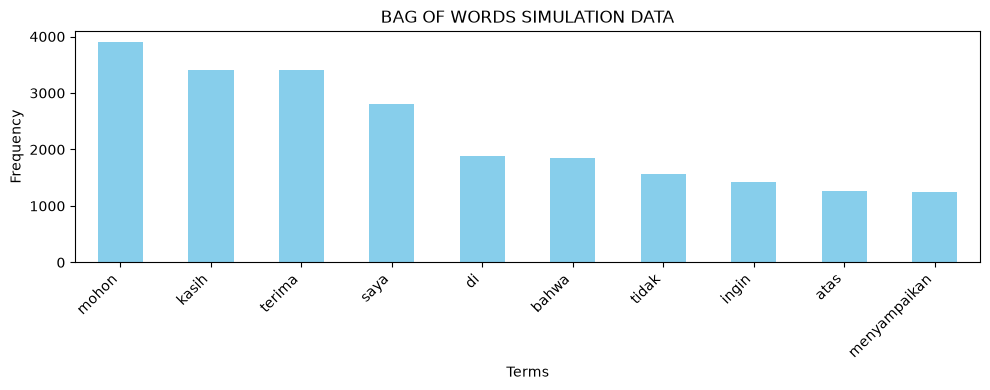


=== BAG OF WORDS TEST DATA ===
   08101744769  08102259657  08103092589  08103474410  08103938983  \
0            0            0            0            0            0   
1            0            0            0            0            0   
2            0            0            0            0            0   
3            0            0            0            0            0   
4            0            0            0            0            0   

   08104895665  08105446209  08108930268  08109045630  08121276398  ...  \
0            0            0            0            0            0  ...   
1            0            0            0            0            0  ...   
2            0            0            0            0            0  ...   
3            0            0            0            0            0  ...   
4            0            0            0            0            0  ...   

   wijaya49  wijaya69  wijaya94  wulan  ya  yahoo  yang  yg  yuni  yusuf  
0         0         0

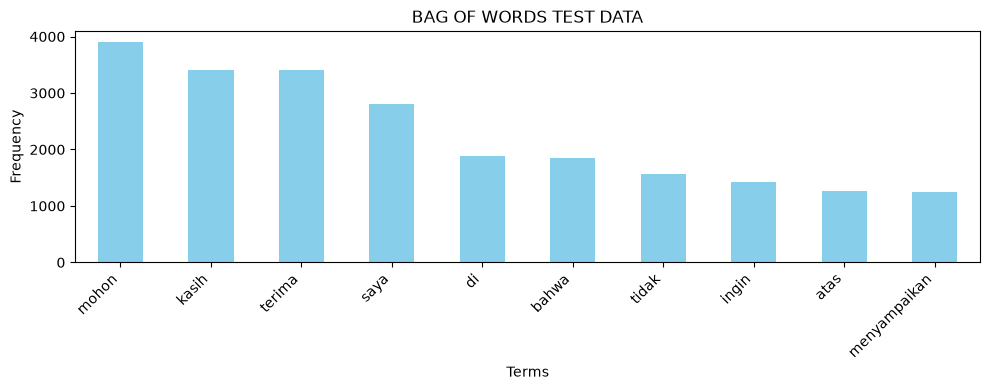

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer


def process_and_visualize_bow(df, column, title="Bag of Words Count"):
  vectorizer = CountVectorizer()
  X = vectorizer.fit_transform(df[column])
  df_bow = pd.DataFrame(
      X.toarray(), columns=vectorizer.get_feature_names_out()
  )

  print(f"\n=== {title} ===")
  print(df_bow.head())

  # Calculate word frequencies and plot top terms
  word_counts = df_bow.sum(axis=0).sort_values(ascending=False)

  plt.figure(figsize=(10, 4))
  word_counts.head(10).plot(kind="bar", color="skyblue")
  plt.title(title)
  plt.xlabel("Terms")
  plt.ylabel("Frequency")
  plt.xticks(rotation=45, ha="right")
  plt.tight_layout()
  plt.show()

  return df_bow


# Execute using 'teks_aduan' as the column name for simulation and test data
df_simulation_bow = process_and_visualize_bow(
    df_simulation, "teks_aduan", "BAG OF WORDS SIMULATION DATA"
)
df_test_bow = process_and_visualize_bow(
    df_test, "teks_aduan", "BAG OF WORDS TEST DATA"
)


=== SIMULATION DATA (Cleaned BoW) ===
   abaikan  acara  administrasi  agar  ahmad  air  aja  akademik  akhir  \
0        0      0             0     0      0    0    0         0      0   
1        0      0             0     0      0    0    0         0      0   
2        0      0             0     0      0    0    0         0      0   
3        0      0             0     0      0    0    0         0      0   
4        0      0             0     0      0    0    0         0      0   

   akibat  ...  wahyuni  warga  wawancara  web  wifi  wijaya  wulan  yahoo  \
0       0  ...        0      0          0    0     0       0      0      0   
1       0  ...        0      0          0    1     0       0      0      0   
2       0  ...        0      0          0    0     0       0      0      0   
3       0  ...        0      0          0    0     0       0      0      0   
4       0  ...        0      0          0    0     0       0      0      0   

   yuni  yusuf  
0     0      0  
1     0

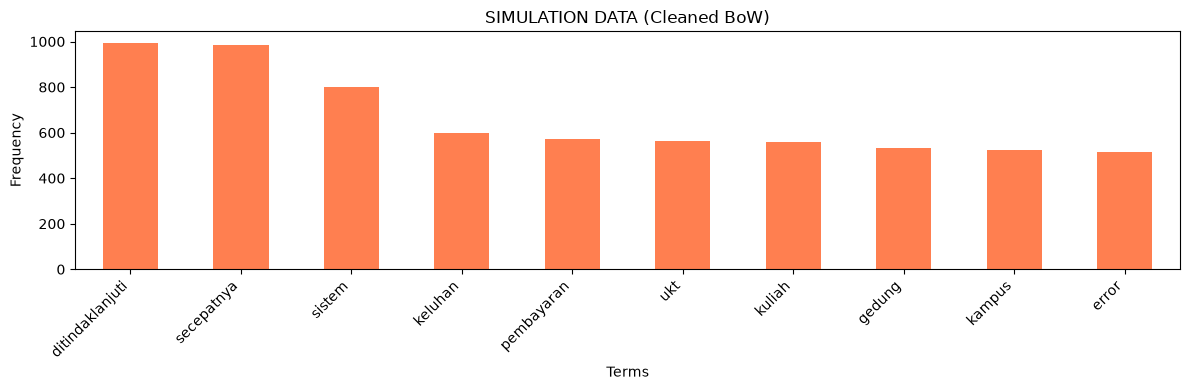


=== TEST DATA (Cleaned BoW) ===
   abaikan  acara  administrasi  agar  ahmad  air  aja  akademik  akhir  \
0        0      0             0     0      0    0    0         0      0   
1        0      0             0     0      0    0    0         0      0   
2        0      0             0     0      0    0    0         0      0   
3        0      0             0     0      0    0    0         0      0   
4        0      0             0     0      0    0    0         0      0   

   akibat  ...  wahyuni  warga  wawancara  web  wifi  wijaya  wulan  yahoo  \
0       0  ...        0      0          0    0     0       0      0      0   
1       0  ...        0      0          0    1     0       0      0      0   
2       0  ...        0      0          0    0     0       0      0      0   
3       0  ...        0      0          0    0     0       0      0      0   
4       0  ...        0      0          0    0     0       0      0      0   

   yuni  yusuf  
0     0      0  
1     0      

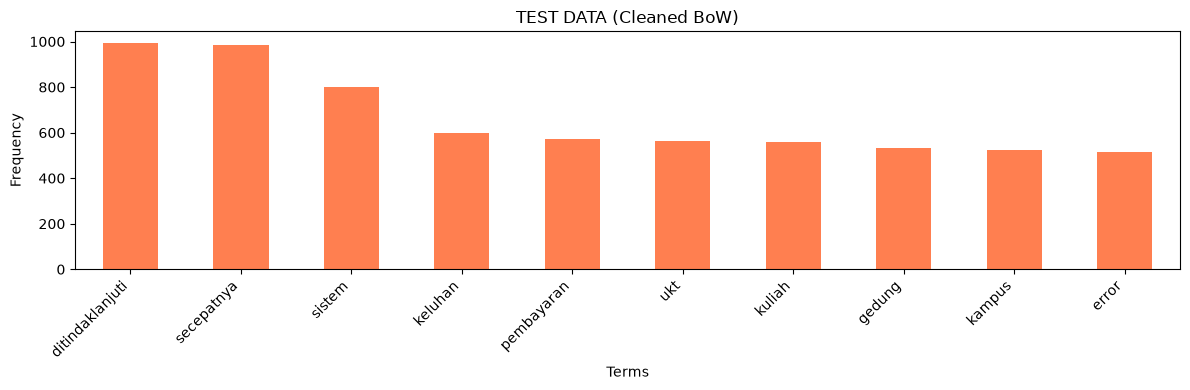

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Expanded stop words including bureaucratic framing and conversational politeness markers
stopwords = [
    # Pronouns & basic connectors
    "yang","dan","di","ke","dari","untuk","dengan","pada",
    "ini","itu","adalah","atau","juga","saya","kamu","mereka",
    "kami","anda","dia","ia","kita","mu","nya",
    # Prepositions & conjunctions
    "bahwa","dalam","sebagai","oleh","saat","ketika","maka","kepada","terhadap",
    "antara","tentang","seperti","bagi","melalui","lewat","tanpa","sehingga","sementara",
    # Adverbs, time markers, auxiliary verbs
    "sudah","belum","akan","jika","karena","tetapi","namun","lagi","lagi-lagi",
    "sangat","lebih","paling","bisa","dapat","harus","perlu","ada","adalah","jadi",
    "hanya","saja","pun","kah","tah","telah","sedang","masih",
    # Conversational & politeness boilerplate
    "terima", "kasih","min","mohon","tolong","ingin","atas","ya","tidak","bukan",
    "baik","hormat","pagi","siang","sore","malam","selamat","pesan","sampaikan",
    "menyampaikan","bantuan","bantuannya","segera","perhatiannya","nama",
    "nim","email", "mau", "saya", "halo", "izin", "nih", 
    "lapor", "melaporkan", "laporan", "laporkan", "permisi", "dibantu", "informasinya",
]


def process_and_visualize_bow_no_stopwords(
    df, column, title="Bag of Words Count (Cleaned)"
):
  # lowercase and remove common noise using analyzer/tokenization preferences
  vectorizer = CountVectorizer(
      stop_words=stopwords,
      lowercase=True,
      token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",  # ignores words shorter than 3 characters (e.g., di, ke, ya)
  )

  X = vectorizer.fit_transform(df[column])
  df_bow = pd.DataFrame(
      X.toarray(), columns=vectorizer.get_feature_names_out()
  )

  print(f"\n=== {title} ===")
  print(df_bow.head())

  word_counts = df_bow.sum(axis=0).sort_values(ascending=False)

  plt.figure(figsize=(12, 4))
  word_counts.head(10).plot(kind="bar", color="coral")
  plt.title(title)
  plt.xlabel("Terms")
  plt.ylabel("Frequency")
  plt.xticks(rotation=45, ha="right")
  plt.tight_layout()
  plt.show()

  return df_bow


# Run simulation and test data with clean settings
df_simulation_bow = process_and_visualize_bow_no_stopwords(
    df_simulation, "teks_aduan", "SIMULATION DATA (Cleaned BoW)"
)
df_test_bow = process_and_visualize_bow_no_stopwords(
    df_test, "teks_aduan", "TEST DATA (Cleaned BoW)"
)

In [21]:
# Check for missing values
print("\n=== MISSING VALUES SIMULATION DATA ===")
df_simulation_missing = df_simulation.isnull().sum()
print(df_simulation_missing[df_simulation_missing > 0])

print("\n=== MISSING VALUES TEST DATA ===")
df_test_missing = df_test.isnull().sum()
print(df_test_missing[df_test_missing > 0])


=== MISSING VALUES SIMULATION DATA ===
kanal               102
tanggal_selesai    1146
dtype: int64

=== MISSING VALUES TEST DATA ===
kanal    102
dtype: int64


**Kesimpulan**
---
Bentuk data : Teks
Dimensi Data: 10300 entry, 13 variabel
Missing Value: var. Kanal: 102 & 102; tanggal selesai (simulasi): 1146
Top Words: [
    Ditindaklanjuti, Secepatnya, Sistem, Keluhan, Pembayaran, UKT, Kuliah, Gedung, Kampus, Error
]
